Name - senuji kehara
ID - sukd2202360

## objective 
This notebook covers data pre processing and exploratory data analysis (EDA) using the dataset 

In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# lord data set and explor data

In [3]:
#lord data
df= pd.read_csv('employee_salary_data.csv')

In [4]:
#view  overview of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       5000 non-null   object 
 1   Age               4800 non-null   float64
 2   Salary            4800 non-null   float64
 3   Department        4800 non-null   object 
 4   Joining_Date      5000 non-null   object 
 5   Experience_Years  4800 non-null   float64
 6   Remote_Work       5000 non-null   object 
dtypes: float64(3), object(4)
memory usage: 273.6+ KB


## STEP 1 - missing value


In [5]:
# 1 .check the issing value
missing_values = df.isnull().sum()
print (missing_values)

Employee_ID           0
Age                 200
Salary              200
Department          200
Joining_Date          0
Experience_Years    200
Remote_Work           0
dtype: int64


In [6]:
# 2. Calculate percentage of missing value (for numerical only)
missing_precentage = (df.isnull().sum()/ len(df))*100
print (missing_precentage)

Employee_ID         0.0
Age                 4.0
Salary              4.0
Department          4.0
Joining_Date        0.0
Experience_Years    4.0
Remote_Work         0.0
dtype: float64


In [7]:
# 2.1 fill in the numerical column with median values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Salary'].fillna(df['Salary'].median(), inplace=True)
df['Experience_Years'].fillna(df['Experience_Years'].median(), inplace=True)

C:\Users\senuj\AppData\Local\Temp\ipykernel_6036\1491102584.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\senuj\AppData\Local\Temp\ipykernel_6036\1491102584.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [8]:
# 3. verify missing values handled
df.isnull().sum()

Employee_ID           0
Age                   0
Salary                0
Department          200
Joining_Date          0
Experience_Years      0
Remote_Work           0
dtype: int64

In [9]:
# fill in the categorical (departent) with the term unknow
df ['Department'].fillna('Unknown',inplace=True)

C:\Users\senuj\AppData\Local\Temp\ipykernel_6036\3375851601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ['Department'].fillna('Unknown',inplace=True)


In [10]:
# 3. verify missing values handled
df.isnull().sum()

Employee_ID         0
Age                 0
Salary              0
Department          0
Joining_Date        0
Experience_Years    0
Remote_Work         0
dtype: int64

## STEP 2- Duplicates Values

In [11]:
# check duplicates value
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [13]:
#if got duplicate
#remove them
 #df_cleaned = df.drop_duplicates()


In [ ]:
#verify dataset size after removing duplicates
df.shape

In [ ]:
#reset the dataset
df_cleaned.reset_index(drop=true, inplace=True)

#sve new data 
df_cleaned.to_csv('cleaned _employee.csv') , inplace =False)
print ("duplicate rows removed and saved to cleaned_employee.csv")

In [ ]:
#df_cleaned = pd.read_csv('cleaned _employee.csv')

## STEP 3- Correcting Data Type

In [14]:
# Check and dsplay data type 
print (df.dtypes)

Employee_ID          object
Age                 float64
Salary              float64
Department           object
Joining_Date         object
Experience_Years    float64
Remote_Work          object
dtype: object


Convert age and experiance year in to Integer


In [16]:
df['Age'] = df['Age'].astype(int)
df['Experience_Years'] = df['Experience_Years'].astype(int)

In [17]:
#set Salary to Flort data ype with 2 decimal points
df['Salary'] = df['Salary'].astype(float)


In [23]:
#covert joinind data to the Date Time format
df['Joining_Date'] = pd.to_datetime(df['Joining_Date'])


In [24]:
#Convert Remote work to categorical attribtes (yes/no)
df['Remote_Work'] =df['Remote_Work'].map({'Yes' :1,'No' :0 })

In [25]:
# verify the change
print(df.dtypes)

Employee_ID                 object
Age                          int32
Salary                     float64
Department                  object
Joining_Date        datetime64[ns]
Experience_Years             int32
Remote_Work                float64
dtype: object


## STEP 4 - Handling Outliers

1. Why shoud we handl Outliers
   - to target the performance modle up than 70% of accuracy result.
2. How todetect outlier in dataset
   - IQR interquartile Rane Mehod : Summary of dtatisticd
   - Boxplot vizualization
   - Z-score (normal distribution) : bell corve
3. how to handle outliers
   - a) remove outlier if less than 20% from the record
   - b) replace outler with mean/miduan values
   - c) trsnsform data ( Data transformation : hot coding encode/lable encode)
4. verify the handled outlier: usig funaction describe()


In [26]:
# Check he summary statistics to check mean,max and min values
print(df.describe())

               Age        Salary         Joining_Date  Experience_Years  \
count  5000.000000   5000.000000                 5000       5000.000000   
mean     42.174400   4975.723438  2006-11-04 12:00:00         18.458600   
min      20.000000      0.551189  2000-01-01 00:00:00         -2.000000   
25%      32.000000   1550.154064  2003-06-03 18:00:00          8.000000   
50%      42.000000   3516.692244  2006-11-04 12:00:00         19.000000   
75%      53.000000   6685.335382  2010-04-07 06:00:00         28.000000   
max      64.000000  39100.048340  2013-09-08 00:00:00         39.000000   
std      12.630403   4902.187069                  NaN         11.993909   

       Remote_Work  
count          0.0  
mean           NaN  
min            NaN  
25%            NaN  
50%            NaN  
75%            NaN  
max            NaN  
std            NaN  


if a column have a min or max value "fr" from the mean values, it might contain outlier

In [40]:
import statistics as stats
#define a function IQR
def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 -1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data [column] < lower_bound) | (data[column] > upper_bound)]

#check the outlier is 'salary' column
outlier_salary = detect_outlier_iqr(df, 'Salary')
print (outlier_salary)

     Employee_ID  Age        Salary   Department Joining_Date  \
19      EMP00020   63  19749.331896        Sales   2000-01-20   
27      EMP00028   63  16101.668906           IT   2000-01-28   
38      EMP00039   40  17260.223283        Sales   2000-02-08   
42      EMP00043   23  21273.042210           IT   2000-02-12   
124     EMP00125   20  18315.244758  Engineering   2000-05-04   
...          ...  ...           ...          ...          ...   
4814    EMP04815   60  15795.898054           HR   2013-03-07   
4837    EMP04838   59  25665.949939           IT   2013-03-30   
4840    EMP04841   57  23515.107580    Marketing   2013-04-02   
4969    EMP04970   32  17600.377699  Engineering   2013-08-09   
4986    EMP04987   26  16734.386940  Engineering   2013-08-26   

      Experience_Years  Remote_Work  
19                   9          NaN  
27                  20          NaN  
38                  14          NaN  
42                   7          NaN  
124                 29       

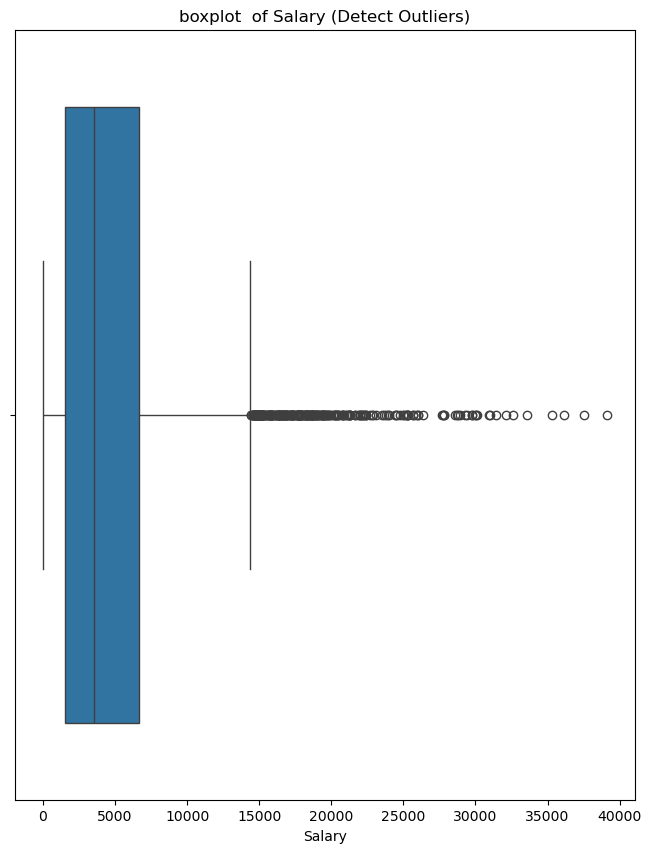

In [41]:
#boxplot
plt.figure(figsize=(8,10))
sns.boxplot(x=df['Salary'])
plt.title("boxplot  of Salary (Detect Outliers)")
plt.show()

#outlier apper aspoint outside the whiskers of the boxplot

if dta follow a normal distribution ,use the Z Scpre method

In [42]:
!pip install scipy

In [44]:
from scipy import stats
#compute Z Score 

df['Z_score_Salary'] = stats.zscore(df['Salary'])

#finf outlier (z-score >3 or <3-)
outlier_z = df [df['Z_score_Salary'].abs() >3]
print(outlier_z)

     Employee_ID  Age        Salary   Department Joining_Date  \
19      EMP00020   63  19749.331896        Sales   2000-01-20   
42      EMP00043   23  21273.042210           IT   2000-02-12   
163     EMP00164   47  29727.666281           IT   2000-06-12   
286     EMP00287   37  29238.785060        Sales   2000-10-13   
323     EMP00324   54  21030.468321  Engineering   2000-11-19   
...          ...  ...           ...          ...          ...   
4756    EMP04757   30  20468.203341           HR   2013-01-08   
4807    EMP04808   37  25294.115435      Unknown   2013-02-28   
4811    EMP04812   63  25982.388114        Sales   2013-03-04   
4837    EMP04838   59  25665.949939           IT   2013-03-30   
4840    EMP04841   57  23515.107580    Marketing   2013-04-02   

      Experience_Years  Remote_Work  Z_score_Salary  
19                   9          NaN        3.013978  
42                   7          NaN        3.324832  
163                 38          NaN        5.049668  
286

How to handle the outlier

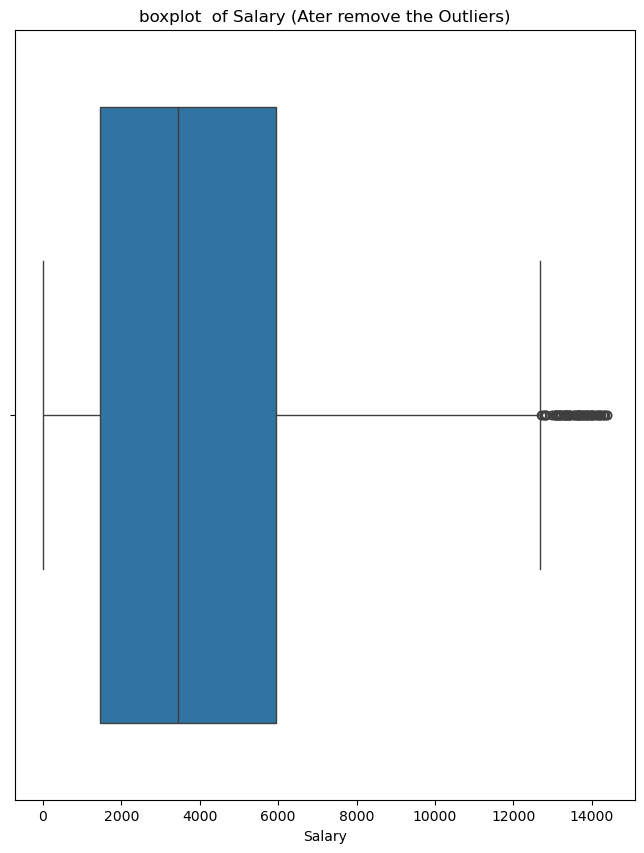

In [51]:
#Calculate the center point using IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outlier
df = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]

#to display using boxplot
plt.figure(figsize=(8,10))
sns.boxplot(x=df['Salary'])
plt.title("boxplot  of Salary (Ater remove the Outliers)")
plt.show()
